In [1]:
from ultralytics import YOLO
from ultralytics.utils.metrics import box_iou
import torch
import napari
import os
from skimage import io, draw, measure
import numpy as np
import pandas as pd
import dask.array as da
from ome_zarr.classes import NgffMultiscales
from ome_zarr.scene import NgffScene
import uuid
import tqdm

from napari_autoscape.models.leica import (
 	StageOverviewRegions,
  	CompoundShape,
  	Point,
  	Vertex,
  	ShapeList,
  	StackList,
  	StackEntry,
  	DefinedRegionEntry,
  	DefinedRegions,
    Regions,
    serialize_to_rgn,
)
from napari_autoscape.focus_detector import (
    FocusLightningModel,
    preprocess_stack,
)

from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

from lxml import etree
import torch

c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.cuda.is_available()

False

In [3]:
model = YOLO(r"train11\weights\best.pt")

In [4]:
viewer = napari.Viewer()

In [5]:
root = r'E:\UserData\Johannes\20260424\2026_04_24_14_09_09--TRG1970_002\TileScan 1'

In [6]:
scene = NgffScene.from_ome_zarr(os.path.join(root, r"scene.ome.zarr"))
scene.images

[NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resize'>),
 NgffMultiscales(method=<Methods.RESIZE: 'resi

In [7]:
def yolo_box2rect(box):
	y_center, x_center, height, width = box
	x_min = int(x_center - width / 2)
	x_max = int(x_center + width / 2)
	y_min = int(y_center - height / 2)
	y_max = int(y_center + height / 2)

	p0 = (x_min, y_min)
	p1 = (x_max, y_min)
	p2 = (x_max, y_max)
	p3 = (x_min, y_max)

	rect = [p0, p1, p2, p3]
	return rect

In [8]:
def sliding_window_inference(image, model, window_size=(640, 640), overlap=0.2):
	height, width = image.shape[:2]
	win_h, win_w = window_size
	stride_h = int(win_h * (1 - overlap))
	stride_w = int(win_w * (1 - overlap))

	windows = {}

	# Generate all window positions
	y_positions = list(range(0, height - win_h + 1, stride_h))
	x_positions = list(range(0, width - win_w + 1, stride_w))

	# Ensure the far edges are covered by adding a final window at the edge
	if y_positions[-1] + win_h < height:
		y_positions.append(height - win_h)
	if x_positions[-1] + win_w < width:
		x_positions.append(width - win_w)

	# Slide windows across image
	for y_offset in y_positions:
		for x_offset in x_positions:
			window = image[y_offset:y_offset+win_h, x_offset:x_offset+win_w]
			window_norm = (window - window.min()) / (window.max() - window.min() + 1e-8) * 255
			windows[(y_offset, x_offset)] = window_norm

	predictions = model(list(windows.values()))
	df = pd.DataFrame()
	for window, prediction in zip(windows.keys(), predictions):
		y_offset, x_offset = window
		for box, conf in zip(prediction.boxes.xywh, prediction.boxes.conf):
			rectangle = yolo_box2rect(box)
			# Shift rectangle coordinates by window offset
			rectangle_shifted = [(y + y_offset, x + x_offset) for (y, x) in rectangle]
			_df = pd.DataFrame({
				'x0': [rectangle_shifted[0][1]],
				'y0': [rectangle_shifted[0][0]],
				'x1': [rectangle_shifted[2][1]],
				'y1': [rectangle_shifted[2][0]],
				'confidence': [conf.item()]
			})
			df = pd.concat([df, _df], ignore_index=True)

	return df

In [9]:
def extract_features(image: np.ndarray, boxes: pd.DataFrame) -> pd.DataFrame:
	"""Basic feature extraction using skimage.measure.regionprops_table."""

	features = pd.DataFrame()

	for _, box in boxes.iterrows():
		x0, y0, x1, y1 = int(box['x0']), int(box['y0']), int(box['x1']), int(box['y1'])
		crop = image[y0:y1, x0:x1]

		_features = pd.DataFrame(measure.regionprops_table(
			label_image=np.ones(crop.shape, dtype=int),  # Dummy label image
			intensity_image=crop,
			properties=[
				"area",
				"mean_intensity",
				"max_intensity",
				"min_intensity",
				"std_intensity"
			],
		))
		_features["x0"] = x0
		_features["y0"] = y0
		_features["x"] = (x0 + x1) / 2
		_features["x1"] = x1
		_features["y1"] = y1
		_features["y"] = (y0 + y1) / 2
		_features["width"] = x1 - x0
		_features["height"] = y1 - y0
		_features["aspect_ratio"] = _features["width"] / _features["height"]
		if "confidence" in box:
			_features["confidence"] = box["confidence"]
		features = pd.concat([features, _features], ignore_index=True)

	# get distance to nearest other box
	positions = features[["x0", "y0", "x1", "y1"]].values
	for i, box in features.iterrows():
		box_coords = np.array([box['x0'], box['y0'], box['x1'], box['y1']])
		other_boxes = np.delete(positions, i, axis=0)
		distances = np.linalg.norm(other_boxes - box_coords, axis=1)
		features.at[i, "nearest_box_distance"] = distances.min()

	# get area over largest intersection with other boxes
	for i, box in features.iterrows():
		box_coords = np.array([box['x0'], box['y0'], box['x1'], box['y1']])
		boxArea = (box_coords[2] - box_coords[0]) * (box_coords[3] - box_coords[1])
		
		other_boxes = np.delete(positions, i, axis=0)
		IoAs = []
		for other in other_boxes:
			xA = max(box_coords[0], other[0])
			yA = max(box_coords[1], other[1])
			xB = min(box_coords[2], other[2])
			yB = min(box_coords[3], other[3])
			interArea = max(0, xB - xA) * max(0, yB - yA)
			
			if boxArea > 0:
				IoAs.append(interArea / boxArea)
		features.at[i, "max_intersection_over_area"] = max(IoAs) if IoAs else 0

	return features

In [10]:
def remove_duplicate_detections(df, iou_threshold=0.5):
	"""Remove duplicate detections in overlap regions using IoU."""
	if len(df) == 0:
		return df
	
	# Sort by confidence (highest first)
	df = df.sort_values('confidence', ascending=False).reset_index(drop=True)
	keep = []

	boxes_xyxy = df[['x0', 'y0', 'x1', 'y1']].values
	ious = box_iou(torch.tensor(boxes_xyxy), torch.tensor(boxes_xyxy)).numpy()
	np.fill_diagonal(ious, 0)  # Ignore self-comparison
	
	for i, row in df.iterrows():
		keep_this = True
		for kept_idx in keep:
			if ious[i, kept_idx] > iou_threshold:
				keep_this = False
				break
		
		if keep_this:
			keep.append(i)
	
	return df.loc[keep].reset_index(drop=True)

In [11]:
viewer.layers.clear()

resolution_level = 2

image_layers = []
shapes_layers = []

for ms in scene.images:
	# retrieve translation and multiscales
	translation = [t for t in scene.metadata.coordinateTransformations if t.input.path == ms.name][0]
	translate = translation.translation
	scale=list(ms.images[resolution_level].scale.values())

	projection = ms.images[resolution_level].data.min(axis=0)
	projection = (projection - projection.min()) / (projection.max() - projection.min()) * 255
	z0 = translate[0] + ms.images[resolution_level].data.shape[0] * scale[0] / 2

	df_rectangles = sliding_window_inference(projection.compute(), model, window_size=(640, 640), overlap=0.2)
	df_rectangles = remove_duplicate_detections(df_rectangles, iou_threshold=0.1)
	df_rectangles = extract_features(projection.compute(), df_rectangles)
	
	rectangles = []
	for _, row in df_rectangles.iterrows():
		x0 = float(row['x0']) * scale[2] + translation.translation[2]
		y0 = float(row['y0']) * scale[1] + translation.translation[1]
		x1 = float(row['x1']) * scale[2] + translation.translation[2] 
		y1 = float(row['y1']) * scale[1] + translation.translation[1]
		rectangles.append([(z0, y0, x0), (z0, y0, x1), (z0, y1, x1), (z0, y1, x0)])

	df_rectangles.drop(columns=["x0", "y0", "x1", "y1"], inplace=True)

	image_layers.append(
		napari.layers.Image(
			[img.data for img in ms.images],
			name=os.path.basename(ms.name),
			translate=translate,
			scale=list(ms.images[0].scale.values())
		)
	)
	shapes_layers.append(napari.layers.Shapes(
			rectangles, shape_type="rectangle", edge_color="red",
			face_color="transparent", features=df_rectangles, edge_width = 0.00001,
			name=os.path.basename(ms.name) + "_detections"
		)
	)

[viewer.add_layer(layer) for layer in image_layers + shapes_layers]



0: 640x640 3 organoids, 16.0ms
1: 640x640 9 organoids, 16.0ms
2: 640x640 20 organoids, 16.0ms
3: 640x640 23 organoids, 16.0ms
4: 640x640 30 organoids, 16.0ms
5: 640x640 6 organoids, 16.0ms
6: 640x640 1 organoid, 16.0ms
7: 640x640 7 organoids, 16.0ms
8: 640x640 18 organoids, 16.0ms
9: 640x640 21 organoids, 16.0ms
10: 640x640 19 organoids, 16.0ms
11: 640x640 32 organoids, 16.0ms
12: 640x640 15 organoids, 16.0ms
13: 640x640 3 organoids, 16.0ms
14: 640x640 8 organoids, 16.0ms
15: 640x640 23 organoids, 16.0ms
16: 640x640 5 organoids, 16.0ms
17: 640x640 5 organoids, 16.0ms
18: 640x640 6 organoids, 16.0ms
19: 640x640 22 organoids, 16.0ms
20: 640x640 6 organoids, 16.0ms
21: 640x640 14 organoids, 16.0ms
22: 640x640 28 organoids, 16.0ms
23: 640x640 8 organoids, 16.0ms
24: 640x640 12 organoids, 16.0ms
25: 640x640 11 organoids, 16.0ms
26: 640x640 20 organoids, 16.0ms
27: 640x640 12 organoids, 16.0ms
28: 640x640 8 organoids, 16.0ms
29: 640x640 33 organoids, 16.0ms
30: 640x640 17 organoids, 16.0ms


[<Image layer 'A1' at 0x2794f122ae0>,
 <Image layer 'A10' at 0x2794eea2d50>,
 <Image layer 'A11' at 0x27903972cc0>,
 <Image layer 'A12' at 0x2790d71aa50>,
 <Image layer 'A2' at 0x27904a0d5b0>,
 <Image layer 'A3' at 0x27904a0cd40>,
 <Image layer 'A4' at 0x27904a0fef0>,
 <Image layer 'A5' at 0x27904b57110>,
 <Image layer 'A7' at 0x279079094f0>,
 <Image layer 'A6' at 0x27904cbce00>,
 <Image layer 'A8' at 0x27904cae6c0>,
 <Image layer 'B1' at 0x27904d7de20>,
 <Image layer 'A9' at 0x27907506300>,
 <Image layer 'B10' at 0x27904df3050>,
 <Image layer 'B11' at 0x27907254350>,
 <Image layer 'B12' at 0x279072e2480>,
 <Image layer 'B2' at 0x279646293a0>,
 <Image layer 'B3' at 0x27906df0c20>,
 <Image layer 'B4' at 0x27906ec42c0>,
 <Image layer 'B7' at 0x2790507c6b0>,
 <Image layer 'B8' at 0x27906f5c170>,
 <Image layer 'B5' at 0x279051de6f0>,
 <Image layer 'B9' at 0x27906607110>,
 <Image layer 'B6' at 0x279065b7b90>,
 <Image layer 'C1' at 0x279070bb680>,
 <Image layer 'C10' at 0x279070ba4b0>,
 <Ima

c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\colormap.py:34: UserWarning: Categorical colormap detected. Setting categorical=True. If the colormap is continuous, set categorical=False explicitly.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `color_indices` to integers.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\colormap.py:34: UserWarning: Categorical colormap detected. Setting categorical=True. If the colormap is continuous, set categorical=False explicitly.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `color_indices` to integer

INFO: No data points found for selected cluster1 in layer H11_detections.


c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\colormap.py:34: UserWarning: Categorical colormap detected. Setting categorical=True. If the colormap is continuous, set categorical=False explicitly.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `color_indices` to integers.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `color_indices` to integers.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `col

...

c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\colormap.py:34: UserWarning: Categorical colormap detected. Setting categorical=True. If the colormap is continuous, set categorical=False explicitly.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `color_indices` to integers.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `color_indices` to integers.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `col

INFO: No data points found for selected cluster1 in layer H12_detections.


c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\colormap.py:34: UserWarning: Categorical colormap detected. Setting categorical=True. If the colormap is continuous, set categorical=False explicitly.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `color_indices` to integers.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `color_indices` to integers.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `col

INFO: No data points found for selected cluster1 in layer H7_detections.


c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\colormap.py:34: UserWarning: Categorical colormap detected. Setting categorical=True. If the colormap is continuous, set categorical=False explicitly.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `color_indices` to integers.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `color_indices` to integers.
  warnings.warn(
c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\biaplotter\artists.py:331: UserWarning: Color indices must be integers for categorical colormap. Change `overlay_colormap` to a continuous colormap or set `col

## Apply focus detection

In [12]:
best_model = FocusLightningModel.load_from_checkpoint(r"logs_focus_detector/lightning_logs/version_6/checkpoints/best.ckpt").eval()

In [13]:
def fit_func(x, a, x0, y0):
    return y0 + a  * (x-x0)**2

In [45]:
selected_layers = [l for l in viewer.layers if "subcluster" in l.name]

crop_size = 256
row_objects = {}
well_objects = {}
stacklist_entries =[]

for layer in selected_layers:
    well = layer.name[:2]
    row = well[0]
    col = well[1]

    if row not in row_objects:
        row_objects[row] = CompoundShape(
        Name="C",
        Identifier=str(uuid.uuid4()),
        Type="CompoundShape",
        Fill=[1, 0, 0, 0],
        Verticies=[],
        Children=[]
    )

for layer in tqdm.tqdm(selected_layers):
    well = layer.name[:2]
    row = well[0]
    col = well[1]

    if well != "B2":
        continue

    if (row, col) not in well_objects:
        well_objects[(row, col)] = CompoundShape(
            Name=str(col),
            Identifier=str(uuid.uuid4()),
            Type="CompoundShape",
            Fill=[1, 0, 0, 0],
            Verticies=[],
            Children=[]
        )
    
    well_obj = well_objects[(row, col)]

    img_layer = [next(l for l in viewer.layers if l.name.startswith(well) and isinstance(l, napari.layers.Image)) for n in viewer.layers][0]
    x = np.linspace(img_layer.translate[0], img_layer.translate[0] + img_layer.data[0].shape[0] * img_layer.scale[0], num=img_layer.data[0].shape[0])

    points = []

    iterator = tqdm.tqdm(enumerate(layer.data), total=len(layer.data), desc=f"{well}")
    for box_idx, box in iterator:
        box_center = box.mean(axis=0)
        position = (box_center - img_layer.translate) / img_layer.scale
        crop = img_layer.data[0][
            :,
            int(position[1] - crop_size // 2):int(position[1] + crop_size // 2),
            int(position[2] - crop_size // 2):int(position[2] + crop_size // 2),
        ]

        if crop.size == 0:
            continue
        offsets = best_model(preprocess_stack(crop.compute())).detach().cpu().numpy().squeeze()
        params, cov = curve_fit(fit_func, x, offsets, bounds=([0, x.min(), -np.inf], [np.inf, x.max(), np.inf]), p0 = [400000000, 0.00295, 0])
        z_pos = params[1]

        pt_uuid = str(uuid.uuid4())

        points.append(
            Point(
                Name=f"{row}{col}_P{box_idx}",
                Tag=f"{row}{col}_P{box_idx}",
                Number=box_idx,
                Identifier=pt_uuid,
                Type="Point",
                Fill=[1, 0, 0, 1],
                Verticies=[Vertex(
                    Y=position[1] * img_layer.scale[1] + img_layer.translate[1],
                    X=position[2] * img_layer.scale[2] + img_layer.translate[2],
                )],
            )
        )
    
        stacklist_entries.append(
            StackEntry(
                Identifier=pt_uuid,
                Begin=f"{z_pos}",
                End=f"{z_pos}",
                SectionCount=1,
                ReferenceX=position[2] * img_layer.scale[2] + img_layer.translate[2],
                ReferenceY=position[1] * img_layer.scale[1] + img_layer.translate[1],
                FocusStabilizerOffset=0,
                FocusStabilizerOffsetFixed=True,
                StackValid=True,
                Marked=True,
            )
        )
    well_obj.Children = points
    row_objects[row].Children.append(well_obj)
    break


  0%|          | 0/90 [00:00<?, ?it/s]c:\Users\Leica-User\miniforge3\envs\autoscape2\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
 96%|█████████▌| 86/90 [00:14<00:00,  6.04it/s]


In [38]:
e = stacklist_entries[0]
e.Begin

'0.0030216024999871667'

(array([          7,           3,           4,           5,          11,          10,           7,           3,           5,          32]),
 array([     2736.2,      2764.7,      2793.3,      2821.8,      2850.4,      2878.9,      2907.4,        2936,      2964.5,      2993.1,      3021.6]),
 <BarContainer object of 10 artists>)

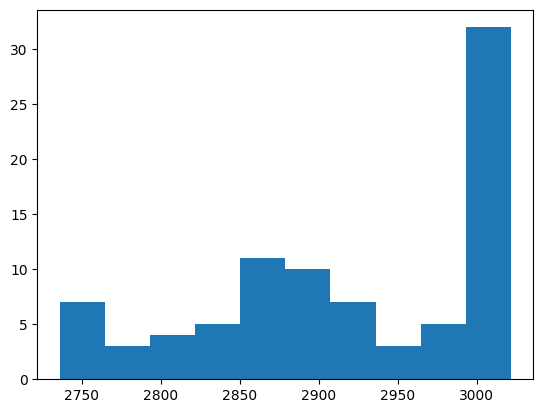

In [44]:
plt.hist([float(e.End)*10e5 for e in stacklist_entries])

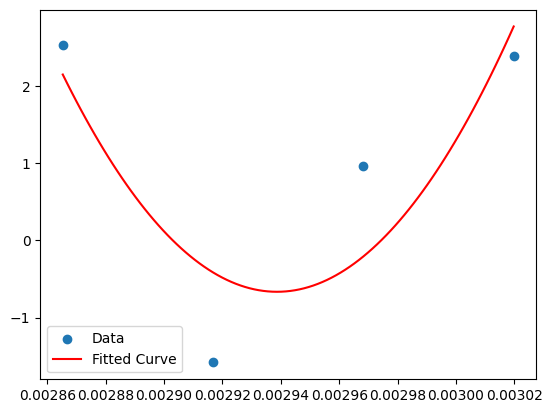

In [140]:
x_plot = np.linspace(x.min(), x.max(), num=100)
#y_plot = -0.3 + 400000000 * (x_plot - 0.00295)**2
y_plot = fit_func(x_plot, *params)

fig, ax = plt.subplots()
ax.scatter(x, offsets, label="Data")
ax.plot(x_plot, y_plot, color='red', label="Fitted Curve")
ax.legend()

## Write detections in Leica format

In [31]:
shapelist = ShapeList(
    Items=row_objects.values()
)

regions = Regions(ShapeList=shapelist)
stacklist = StackList(Entries=stacklist_entries)
defined_regions = DefinedRegions(Entries=[])

stage_overview = StageOverviewRegions(
    Regions=regions,
	DefinedRegions=defined_regions,
	StackList=stacklist,
)

In [32]:
if os.path.exists("output.rgn"):
    os.remove("output.rgn")

xml_str = serialize_to_rgn(stage_overview)
# Parse and pretty-print with lxml, omitting XML declaration
xml_root = etree.fromstring(xml_str)
pretty_xml = etree.tostring(
    xml_root,
    pretty_print=True,
    encoding="utf-8",
    xml_declaration=False  # Omit the XML declaration
).decode("utf-8")

# Save to file
with open("output.rgn", "w") as f:
    f.write(pretty_xml)

## ...just old code...

In [70]:
rowC_uid = str(uuid.uuid4())
rowC = CompoundShape(
    Name="C",
    Identifier=rowC_uid,
    Type="CompoundShape",
    Fill=[1, 0, 0, 0],
    Verticies=[],
    Children=[]
)

rowD_uid = str(uuid.uuid4())
rowD = CompoundShape(
    Name="D",
    Identifier=rowD_uid,
    Type="CompoundShape",
    Fill=[1, 0, 0, 0],
    Verticies=[],
    Children=[]
)

col_C4_uid = str(uuid.uuid4())
col_C4 = CompoundShape(
    Name="4",
    Identifier=col_C4_uid,
    Type="CompoundShape",
    Fill=[0, 1, 0, 0],
    Verticies=[],
    Children=[],
)

col_C5_uid = str(uuid.uuid4())
col_C5 = CompoundShape(
    Name="5",
    Identifier=col_C5_uid,
    Type="CompoundShape",
    Fill=[0, 0, 1, 0],
    Verticies=[],
    Children=[],
)

col_D4_uid = str(uuid.uuid4())
col_D4 = CompoundShape(
    Name="4",
    Identifier=col_D4_uid,
    Type="CompoundShape",
    Fill=[0, 1, 0, 0],
    Verticies=[],
    Children=[],
)

col_D5_uid = str(uuid.uuid4())
col_D5 = CompoundShape(
    Name="5",
    Identifier=col_D5_uid,
    Type="CompoundShape",
    Fill=[0, 0, 1, 0],
    Verticies=[],
    Children=[],
)

defined_regions = DefinedRegions(
        Entries=[],
    )

In [72]:
positions = []

final_layers = viewer.layers[-4:]
stacklist_entries = []


i_point = 0
for layer in final_layers:
    row = layer.name[0]
    col = layer.name[1]
    
    for box in layer.data:
        box_center = box.mean(axis=0)
        position_uid = uuid.uuid4()

        stacklist_entry = StackEntry(
            Identifier=str(position_uid),
            Begin=f"{box_center[0]}",
            End=f"{box_center[0]}",
            SectionCount=1,
            ReferenceX=0.0465016000,
            ReferenceY=0.0255676000,
            FocusStabilizerOffset=0.0210407929,
            FocusStabilizerOffsetFixed=True,
            StackValid=True,
            Marked=True,
        )
        stacklist_entries.append(stacklist_entry)

        if row == "C":
            if col == "4":
                col_C4.Children.append(Point(
                    Name=f"P{i_point}",
                    Tag=f"P{i_point}",
                    Identifier=str(position_uid),
                    Type="Point",
                    Fill=[0, 1, 0, 0],
                    Verticies=[Vertex(X=box_center[2], Y=box_center[1])],
                    ),
                )
            elif col == "5":
                col_C5.Children.append(Point(
                    Name=f"P{i_point}",
                    Tag=f"P{i_point}",
                    Identifier=str(position_uid),
                    Type="Point",
                    Fill=[0, 0, 1, 0],
                    Verticies=[Vertex(X=box_center[2], Y=box_center[1])],
                    ),
                )
        elif row == "D":
            if col == "4":
                col_D4.Children.append(Point(
                    Name=f"P{i_point}",
                    Tag=f"P{i_point}",
                    Identifier=str(position_uid),
                    Type="Point",
                    Fill=[0, 1, 0, 0],
                    Verticies=[Vertex(X=box_center[2], Y=box_center[1])],
                    ),
                )
            elif col == "5":
                col_D5.Children.append(Point(
                    Name=f"P{i_point}",
                    Tag=f"P{i_point}",
                    Identifier=str(position_uid),
                    Type="Point",
                    Fill=[0, 0, 1, 0],
                    Verticies=[Vertex(X=box_center[2], Y=box_center[1])],
                    ),
                )
        i_point += 1

In [73]:
rowC.Children = [col_C4, col_C5]
rowD.Children = [col_D4, col_D5]

shapelist = ShapeList(
        Items=[
            rowC,
            rowD,
        ]
	)

regions = Regions(ShapeList=shapelist)
stacklist = StackList(Entries=stacklist_entries)

In [ ]:
stacklist = StackList(
        Entries=[
            
            # Add more entries as needed
        ],
    )

defined_regions = DefinedRegions(
        Entries=[
            DefinedRegionEntry(
                Identifier="7acd538d-f2e4-438a-caba-bcb44045f534",
                HolderRow=0,
                HolderColumn=0,
                CarrierIndex=0,
                ChamberRow=0,
                ChamberColumn=0,
                ChamberImageIndex=-1,
                MosaicRows=0,
                MosaicColumns=0,
            ),
            # Add more entries as needed
        ],
    )

col = CompoundShape(
    Name="9",
    Identifier="d9c8e1b0-5a3e-4f8b-9c7a-2f1b2c3d4e5f",
    Type="CompoundShape",
    Fill=[0, 1, 0, 0],
    Verticies=[],
    Children=[
        Point(
            Name="test",
            Tag="P2",
            Identifier="12345678-90ab-cdef-1234-567890abcdef",
            Type="Point",
            Fill=[0, 1, 0, 0],
            Verticies=[Vertex(X=box_center[1], Y=box_center[0])],
        ),
        # Add more Points or CompoundShapes as needed
    ],
)

row = CompoundShape(
    Name="E",
    Identifier="10fac5e0-dcaa-4138-77b7-32708f3b5bb6",
    Type="CompoundShape",
    Fill=[1, 0, 0, 0],
    Verticies=[],
    Children=[col]
)

shapelist = ShapeList(
        Items=[
            row,
        ]
	)

regions = Regions(ShapeList=shapelist)

In [74]:
stage_overview = StageOverviewRegions(
    Regions=regions,
	DefinedRegions=defined_regions,
	StackList=stacklist,
)

In [75]:
if os.path.exists("output.rgn"):
    os.remove("output.rgn")

xml_str = serialize_to_rgn(stage_overview)
# Parse and pretty-print with lxml, omitting XML declaration
xml_root = etree.fromstring(xml_str)
pretty_xml = etree.tostring(
    xml_root,
    pretty_print=True,
    encoding="utf-8",
    xml_declaration=False  # Omit the XML declaration
).decode("utf-8")

# Save to file
with open("output.rgn", "w") as f:
    f.write(pretty_xml)